In [13]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [14]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
)

def web_search(state: AgentState):
    query = state["query"]
    response = tavily_search_tool.invoke({'query': query})
    print(f"web search response: {response}")
    return {'context': response}

In [15]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [16]:
from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

def web_generate(state: AgentState):
    query = state['query']
    context = state['context']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [17]:
mini_llm = ChatOpenAI(model='gpt-4o-mini')

def basic_generate(state: AgentState):
    query = state['query']
    response = mini_llm.invoke(query)
    return {'answer': response}

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class RouteResponse(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="답변할 대상"
    )

router_system_prompt = """
당신은 사용자의 질문을 'vector_store', 'llm' 또는 'web_search'로 연결(routing)하는 데 전문가입니다.
아래 규칙에 따라 라우팅하세요.

규칙
'vector_store': 한국의 소득세법
'llm': 간단한 질문
'web_search': 그 외 질문
"""

router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

router_llm = ChatOpenAI(
    model="gpt-4o-mini"
).with_structured_output(RouteResponse)

def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | router_llm
    response = router_chain.invoke({'query': query})
    print(f"router: {response}")
    return response.target


In [19]:
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

In [20]:
from income_tax_graph import graph as imcome_tax_agent

"""
3.5.corrective-rag notebook을 export

export 시 아래와 같이 수정 후 import
- graph 이하 삭제
- %pip install -q langchain-tavily 삭제
"""
graph_builder.add_node('imcome_tax_agent', imcome_tax_agent)

In [21]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'vector_store': 'imcome_tax_agent',
        'llm': 'basic_generate',
        'web_search': 'web_search'
    }
)

graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('web_generate', END)
graph_builder.add_edge('basic_generate', END)
graph_builder.add_edge('imcome_tax_agent', END)

In [22]:
graph = graph_builder.compile()

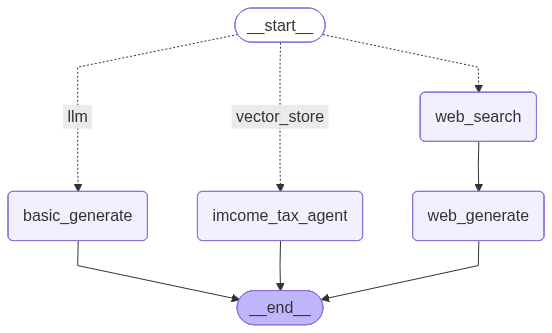

In [23]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
"""
소득세 질문 -> vector_store
"""

inital_state = {'query': '연봉 5천만원인 거주자의 소득세는?'}
graph.invoke(inital_state)

router: target='vector_store'
context == [Document(id='289e9e4a-2425-4ae1-a933-98d388b6780e', metadata={'source': './documents/income_tax.txt'}, page_content='| 총급여액                      | 공제액                                             |\n|-------------------------------|---------------------------------------------------|\n| 500만원 이하                     | 총 급여액의 100분의 70                               |\n| 500만원 초과 1천 500만원 이하 | 350만원+(500만원을 초과하는 금액의 100분의 40)        |\n| 1천 500만원 초과 3천 500만원 이하 | 750만원+(1천 500만원을 초과하는 경우의 100분의 15)   |\n| 3천 500만원 초과 1억원 이하       | 1천 200만원+(3천 500만원을 초과하는 금액의 100분의 5)|\n| 1억원 초과                      | 1천 475만원+(1억원을 초과하는 금액의 100분의 2)       |\n② 일용근로자에 대한 공제액은 제1항에도 불구하고 1일 15만원으로 한다.<개정 2018. 12. 31.>\n③ 근로소득이 있는 거주자의 해당 과세기간의 총급여액이 제1항 또는 제2항의 공제액에 미달하는 경우에는 그 총급여액을 공제액으로 한다.\n④ 제1항부터 제3항까지의 규정에 따른 공제를 “근로소득공제”라 한다.\n⑤ 제1항의 경우에 2인 이상으로부터 근로소득을 받는 사람(일용근로자는 제외한다)에 대하여는 그 근로소득의 합계액을 총급여액으로 하여 제1항에 따라 계산한 근로소득공제액을 총급여액에서 공제한다.<개정 2010. 12. 27.>\n⑥ 삭제

{'query': '연봉 5천만원인 거주자의 소득세는?',
 'context': [Document(id='289e9e4a-2425-4ae1-a933-98d388b6780e', metadata={'source': './documents/income_tax.txt'}, page_content='| 총급여액                      | 공제액                                             |\n|-------------------------------|---------------------------------------------------|\n| 500만원 이하                     | 총 급여액의 100분의 70                               |\n| 500만원 초과 1천 500만원 이하 | 350만원+(500만원을 초과하는 금액의 100분의 40)        |\n| 1천 500만원 초과 3천 500만원 이하 | 750만원+(1천 500만원을 초과하는 경우의 100분의 15)   |\n| 3천 500만원 초과 1억원 이하       | 1천 200만원+(3천 500만원을 초과하는 금액의 100분의 5)|\n| 1억원 초과                      | 1천 475만원+(1억원을 초과하는 금액의 100분의 2)       |\n② 일용근로자에 대한 공제액은 제1항에도 불구하고 1일 15만원으로 한다.<개정 2018. 12. 31.>\n③ 근로소득이 있는 거주자의 해당 과세기간의 총급여액이 제1항 또는 제2항의 공제액에 미달하는 경우에는 그 총급여액을 공제액으로 한다.\n④ 제1항부터 제3항까지의 규정에 따른 공제를 “근로소득공제”라 한다.\n⑤ 제1항의 경우에 2인 이상으로부터 근로소득을 받는 사람(일용근로자는 제외한다)에 대하여는 그 근로소득의 합계액을 총급여액으로 하여 제1항에 따라 계산한 근로소득공제액을 총급여액에서 공제한다.<개정 2010. 12. 27.>\n

In [29]:
"""
간단한 질문 -> llm
"""

inital_state = {'query': '대한민국의 수도는?'}
graph.invoke(inital_state)

router: target='llm'


{'query': '대한민국의 수도는?',
 'answer': AIMessage(content='대한민국의 수도는 서울입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bf8989a65a', 'id': 'chatcmpl-DcheqyxhGFjp9e2wOgngWPOa4iZYp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e0002-fb25-7143-b7d5-4d5279da12e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}

In [30]:
"""
기타 -> web_search
"""

inital_state = {'query': '강남역 맛집은?'}
graph.invoke(inital_state)

router: target='web_search'
web search response: {'query': '강남역 맛집은?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://jdblue2022.tistory.com/entry/%EA%B0%95%EB%82%A8%EC%97%AD-%EB%A7%9B%EC%A7%91-%EB%B2%A0%EC%8A%A4%ED%8A%B810', 'title': '강남역 맛집 베스트10 추천 2024 플레이스 맛집', 'content': '# 강남역 맛집 베스트10 추천 2024 플레이스 맛집. 오늘은 서울시 강남의 대표 상권으로 유명한 강남역의 소문난 맛집 베스트 10곳을 소개해드리고자 하는데\xa0양대 포털의\xa0플레이스를 중심으로 순위를 취합하여 강남역 로컬 맛집들과 함께 여러 음식점을\xa0묶어서 강남역\xa0맛집을 정리해드리고자 합니다. 강남역 맛집 베스트10 음식점 주요 메뉴. 강남역 땀땀 플레이스(구글 평점 4.1). 강남역 마녀주방 플레이스(구글 평점 4.2). 이어지는 강남역 맛집은 강남역 11번 출구 근처에 위치하고 있는 가성비 레스토랑 마녀주방 강남점입니다. 강남역 미도인 플레이스(구글 평점 4.2). 2만 원 이하의 가격으로 드실 수 있는 가정식 등심 스테이크와 바질 크림 새우 파스타에 사이드 메뉴로 스카치 에그도 드시기 좋은 강남역 CGV 맛집입니다. 강남역 을지다락 플레이스(구글 평점 4.3). 강남역 하이디라오 플레이스(구글 평점 4.2). 강남역 어거스트힐 플레이스(구글 평점 4.3). 이어지는 강남역 맛집은 강남역 CGV 근처에 위치하고 있는 스테이크 전문 레스토랑 어거스트 힐 강남점입니다. 강남역 바비레드 플레이스(구글 평점 4.3). 이어지는 강남역 맛집 역시 강남역 CGV 근처에 위치하고 있는 이탈리안 레스토랑 바비레드 강남본점입니다. 이렇게 서울의 대표 상권 중 하나인 강남역 근처의 소문난 맛집

{'query': '강남역 맛집은?',
 'context': {'query': '강남역 맛집은?',
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://jdblue2022.tistory.com/entry/%EA%B0%95%EB%82%A8%EC%97%AD-%EB%A7%9B%EC%A7%91-%EB%B2%A0%EC%8A%A4%ED%8A%B810',
    'title': '강남역 맛집 베스트10 추천 2024 플레이스 맛집',
    'content': '# 강남역 맛집 베스트10 추천 2024 플레이스 맛집. 오늘은 서울시 강남의 대표 상권으로 유명한 강남역의 소문난 맛집 베스트 10곳을 소개해드리고자 하는데\xa0양대 포털의\xa0플레이스를 중심으로 순위를 취합하여 강남역 로컬 맛집들과 함께 여러 음식점을\xa0묶어서 강남역\xa0맛집을 정리해드리고자 합니다. 강남역 맛집 베스트10 음식점 주요 메뉴. 강남역 땀땀 플레이스(구글 평점 4.1). 강남역 마녀주방 플레이스(구글 평점 4.2). 이어지는 강남역 맛집은 강남역 11번 출구 근처에 위치하고 있는 가성비 레스토랑 마녀주방 강남점입니다. 강남역 미도인 플레이스(구글 평점 4.2). 2만 원 이하의 가격으로 드실 수 있는 가정식 등심 스테이크와 바질 크림 새우 파스타에 사이드 메뉴로 스카치 에그도 드시기 좋은 강남역 CGV 맛집입니다. 강남역 을지다락 플레이스(구글 평점 4.3). 강남역 하이디라오 플레이스(구글 평점 4.2). 강남역 어거스트힐 플레이스(구글 평점 4.3). 이어지는 강남역 맛집은 강남역 CGV 근처에 위치하고 있는 스테이크 전문 레스토랑 어거스트 힐 강남점입니다. 강남역 바비레드 플레이스(구글 평점 4.3). 이어지는 강남역 맛집 역시 강남역 CGV 근처에 위치하고 있는 이탈리안 레스토랑 바비레드 강남본점입니다. 이렇게 서울의 대표 상권 중 하나인 강남역 근처의 소문난 맛